In [ ]:
import torch
import os
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from IPython.display import HTML, Markdown, display

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
from google.colab import files
files.upload()

In [ ]:
from diffusion_utilities import (
    ResidualConvBlock,
    UnetUp,
    UnetDown,
    EmbedFC,
    plot_sample,
    CustomDataset,
    transform
)

In [ ]:
timesteps = 500
beta1 = 1e-4
beta2 = 0.02

n_feat = 64
n_cfeat = 5
height = 16

batch_size = 100
n_epoch = 32
lrate = 1e-3

save_dir = "./weights/"

In [ ]:
b_t = beta1 + (beta2 - beta1) * torch.linspace(0, 1, timesteps + 1, device=device)
a_t = 1 - b_t
ab_t = torch.cumsum(a_t.log(), dim=0).exp()
ab_t[0] = 1

In [ ]:
class ContextUnet(nn.Module):
    def __init__(self, in_channels, n_feat=256, n_cfeat=10, height=28):
        super(ContextUnet, self).__init__()

        self.in_channels = in_channels
        self.n_feat = n_feat
        self.n_cfeat = n_cfeat
        self.h = height

        self.init_conv = ResidualConvBlock(in_channels, n_feat, is_res=True)

        self.down1 = UnetDown(n_feat, n_feat)
        self.down2 = UnetDown(n_feat, 2 * n_feat)

        self.to_vec = nn.Sequential(nn.AvgPool2d((4)), nn.GELU())

        self.timeembed1 = EmbedFC(1, 2 * n_feat)
        self.timeembed2 = EmbedFC(1, 1 * n_feat)
        self.contextembed1 = EmbedFC(n_cfeat, 2 * n_feat)
        self.contextembed2 = EmbedFC(n_cfeat, 1 * n_feat)

        self.up0 = nn.Sequential(
            nn.ConvTranspose2d(2 * n_feat, 2 * n_feat, self.h // 4, self.h // 4),
            nn.GroupNorm(8, 2 * n_feat),
            nn.ReLU(),
        )

        self.up1 = UnetUp(4 * n_feat, n_feat)
        self.up2 = UnetUp(2 * n_feat, n_feat)

        self.out = nn.Sequential(
            nn.Conv2d(2 * n_feat, n_feat, 3, 1, 1),
            nn.GroupNorm(8, n_feat),
            nn.ReLU(),
            nn.Conv2d(n_feat, self.in_channels, 3, 1, 1),
        )

    def forward(self, x, t, c=None):
        x = self.init_conv(x)
        down1 = self.down1(x)
        down2 = self.down2(down1)

        hiddenvec = self.to_vec(down2)

        if c is None:
            c = torch.zeros(x.shape[0], self.n_cfeat).to(x)

        cemb1 = self.contextembed1(c).view(-1, self.n_feat * 2, 1, 1)
        temb1 = self.timeembed1(t).view(-1, self.n_feat * 2, 1, 1)
        cemb2 = self.contextembed2(c).view(-1, self.n_feat, 1, 1)
        temb2 = self.timeembed2(t).view(-1, self.n_feat, 1, 1)

        up1 = self.up0(hiddenvec)
        up2 = self.up1(cemb1 * up1 + temb1, down2)
        up3 = self.up2(cemb2 * up2 + temb2, down1)

        out = self.out(torch.cat((up3, x), 1))
        return out

In [ ]:
nn_model = ContextUnet(in_channels=3, n_feat=n_feat, n_cfeat=n_cfeat, height=height).to(device)

In [ ]:
dataset = CustomDataset(
    "./sprites_1788_16x16.npy",
    "./sprite_labels_nc_1788_16x16.npy",
    transform,
    null_context=False
)

dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=1)
optim = torch.optim.Adam(nn_model.parameters(), lr=lrate)

sprite shape: (89400, 16, 16, 3)
labels shape: (89400, 5)


In [ ]:
def perturb_input(x, t, noise):
    return ab_t.sqrt()[t, None, None, None] * x + (1 - ab_t[t, None, None, None]).sqrt() * noise

In [ ]:
def denoise_add_noise(x, t, pred_noise, z=None):
    if z is None:
        z = torch.randn_like(x)
    noise = b_t.sqrt()[t] * z
    mean = (x - pred_noise * ((1 - a_t[t]) / (1 - ab_t[t]).sqrt())) / a_t[t].sqrt()
    return mean + noise

In [ ]:
nn_model.train()

for ep in range(n_epoch):
    print(f'epoch {ep}')

    optim.param_groups[0]['lr'] = lrate * (1 - ep / n_epoch)

    pbar = tqdm(dataloader, mininterval=2)

    for x, c in pbar:
        optim.zero_grad()

        x = x.to(device)
        c = c.to(device)

        context_mask = torch.bernoulli(torch.zeros(c.shape[0]) + 0.9).to(device)
        c = c * context_mask.unsqueeze(-1)

        noise = torch.randn_like(x)
        t = torch.randint(1, timesteps + 1, (x.shape[0],), device=device)

        x_pert = perturb_input(x, t, noise)

        pred_noise = nn_model(x_pert, t / timesteps, c=c)

        loss = F.mse_loss(pred_noise, noise)
        loss.backward()

        optim.step()

        pbar.set_description(f"loss: {loss.item():.4f}")

    if ep % 4 == 0 or ep == int(n_epoch - 1):
        if not os.path.exists(save_dir):
            os.mkdir(save_dir)
        torch.save(nn_model.state_dict(), save_dir + f"context_model_{ep}.pth")

epoch 0


loss: 0.1555: 100%|██████████| 894/894 [00:42<00:00, 21.24it/s]


epoch 1


loss: 0.1128: 100%|██████████| 894/894 [00:35<00:00, 24.92it/s]


epoch 2


...

loss: 0.0393: 100%|██████████| 894/894 [00:32<00:00, 27.65it/s]


epoch 30


loss: 0.0446: 100%|██████████| 894/894 [00:32<00:00, 27.62it/s]


epoch 31


loss: 0.0351: 100%|██████████| 894/894 [00:34<00:00, 25.75it/s]


In [ ]:
@torch.no_grad()
def sample_ddpm_context(n_sample, context, save_rate=20):

    samples = torch.randn(n_sample, 3, height, height).to(device)

    intermediate = []

    for i in range(timesteps, 0, -1):

        t = torch.tensor([i / timesteps])[:, None, None, None].to(device)

        z = torch.randn_like(samples) if i > 1 else 0

        eps = nn_model(samples, t, c=context)
        samples = denoise_add_noise(samples, i, eps, z)

        if i % save_rate == 0 or i == timesteps or i < 8:
            intermediate.append(samples.detach().cpu().numpy())

    intermediate = np.stack(intermediate)
    return samples, intermediate

In [ ]:
plt.clf()

ctx = F.one_hot(torch.randint(0, 5, (32,)), 5).float().to(device)

samples, intermediate = sample_ddpm_context(32, ctx)

animation = plot_sample(intermediate, 32, 4, save_dir, "ani", None, save=False)

HTML(animation.to_jshtml())

<Figure size 640x480 with 0 Axes>

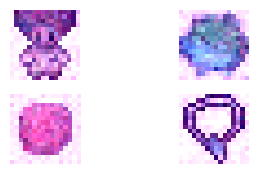

In [ ]:
def show_images(imgs, nrow=2):
    _, axs = plt.subplots(nrow, imgs.shape[0] // nrow, figsize=(4,2))
    axs = axs.flatten()
    for img, ax in zip(imgs, axs):
        img = (img.permute(1,2,0).cpu().numpy() +1)/2
        ax.imshow(img)
        ax.axis("off")
    plt.show()

ctx = torch.tensor([
    [1,0,0,0,0],
    [0,1,0,0,0],
    [0,0,1,0,0],
    [0,0,0,1,0],
]).float().to(device)

samples, _ = sample_ddpm_context(ctx.shape[0], ctx)
show_images(samples)

In [ ]:
def denoise_ddim(x, t, t_prev, pred_noise):
    ab = ab_t[t]
    ab_prev = ab_t[t_prev]

    x0_pred = (x - (1 - ab).sqrt() * pred_noise) / ab.sqrt()
    dir_xt = (1 - ab_prev).sqrt() * pred_noise

    return ab_prev.sqrt() * x0_pred + dir_xt

In [ ]:
@torch.no_grad()
def sample_ddim_context(n_sample, context, n=20):

    samples = torch.randn(n_sample, 3, height, height).to(device)

    intermediate = []
    step_size = timesteps // n

    for i in range(timesteps, 0, -step_size):

        t = torch.tensor([i / timesteps])[:, None, None, None].to(device)

        eps = nn_model(samples, t, c=context)
        t_prev = max(i - step_size, 1)

        samples = denoise_ddim(samples, i, t_prev, eps)

        intermediate.append(samples.detach().cpu().numpy())

    intermediate = np.stack(intermediate)
    return samples, intermediate

In [ ]:
display(Markdown(r"""
### Question

Write the DDPM and DDIM equations and explain how they work. What is the difference between them and their advantages?

### Réponse

DDPM repose sur un processus de diffusion stochastique où du bruit gaussien est ajouté progressivement, puis retiré étape par étape :

x_t = sqrt(alpha_t) x_{t-1} + sqrt(1 - alpha_t) epsilon

Le processus inverse utilise un réseau pour prédire le bruit et reconstruire l’image.

DDIM modifie ce processus en le rendant déterministe. Il reconstruit directement l’image précédente sans ajouter de bruit aléatoire :

x_0 = (x_t - sqrt(1 - alpha_bar_t) epsilon) / sqrt(alpha_bar_t)

Puis :

x_{t-1} = sqrt(alpha_bar_{t-1}) x_0 + sqrt(1 - alpha_bar_{t-1}) epsilon

Différences :
- DDPM est stochastique → plus de diversité
- DDIM est déterministe → plus rapide

Avantages :
- DDPM : meilleure qualité et diversité
- DDIM : génération beaucoup plus rapide
"""))


### Question

Write the DDPM and DDIM equations and explain how they work. What is the difference between them and their advantages?

### Réponse

DDPM repose sur un processus de diffusion stochastique où du bruit gaussien est ajouté progressivement, puis retiré étape par étape :

x_t = sqrt(alpha_t) x_{t-1} + sqrt(1 - alpha_t) epsilon

Le processus inverse utilise un réseau pour prédire le bruit et reconstruire l’image.

DDIM modifie ce processus en le rendant déterministe. Il reconstruit directement l’image précédente sans ajouter de bruit aléatoire :

x_0 = (x_t - sqrt(1 - alpha_bar_t) epsilon) / sqrt(alpha_bar_t)

Puis :

x_{t-1} = sqrt(alpha_bar_{t-1}) x_0 + sqrt(1 - alpha_bar_{t-1}) epsilon

Différences :
- DDPM est stochastique → plus de diversité
- DDIM est déterministe → plus rapide

Avantages :
- DDPM : meilleure qualité et diversité
- DDIM : génération beaucoup plus rapide
